# Caso d'uso aziendale: Previsione della Progressione del Diabete in Pazienti a Rischio

In questo progetto viene sviluppato un modello di regressione per
prevedere la progressione del diabete a partire da alcune
informazioni cliniche dei pazienti.

Utilizzando il dataset Diabetes di scikit-learn vengono eseguite
diverse fasi di analisi dei dati, tra cui esplorazione delle
variabili, preprocessing, selezione delle feature più rilevanti
e costruzione del modello predittivo.
L’obiettivo è comprendere quali variabili influenzano maggiormente
la progressione della malattia e costruire un modello in grado
di fornire previsioni utili a supporto delle decisioni cliniche.

In [ ]:
# 1. Caricamento del Dataset

import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(scaled=False) # Carichiamo il dataset non scalato

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="progression")

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


In [ ]:
# 2. Analisi Esplorativa dei Dati (EDA)

X.describe() # Stampiamo le statistiche descrittive

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000


In [ ]:
X.info() # Informazioni generali sul dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [ ]:
# Uniamo feature e target per analizzare le correlazioni
df = X.copy()
df["target"] = y

# Calcoliamo la correlazione tra le feature e il target
df.corr()["target"].sort_values(ascending=False)

,target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


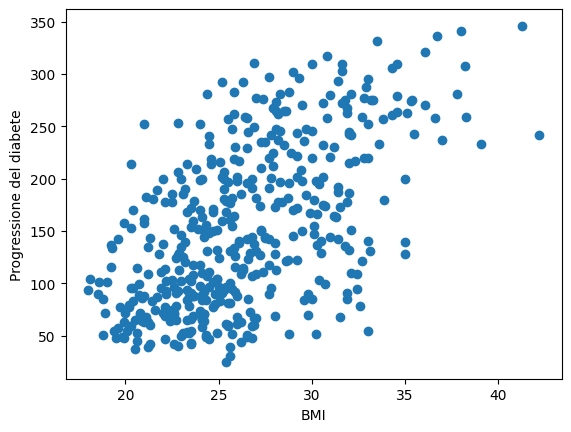

In [ ]:
# 2b. EDA Grafica

# Aggiungiamo grafici per esplorare i dati
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(X["bmi"], y)
plt.xlabel("BMI")
plt.ylabel("Progressione del diabete")
plt.show()

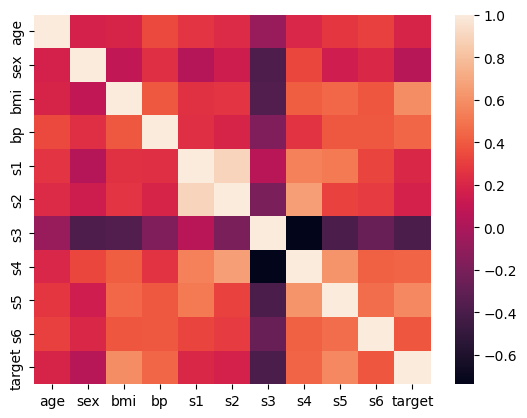

In [ ]:
# Heatmap delle correlazioni
corr = df.corr()
sns.heatmap(corr, annot=False)
plt.show()

In [ ]:
# Dal grafico scatter osserviamo una relazione positiva tra BMI e la progressione del diabete
# La heatmap mostra che alcune variabili, come BMI e S5, sono più correlate al target

In [ ]:
# 3. Pulizia e Pre-processing dei Dati

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Eseguiamo lo split prima dello scaling, evitiamo di utilizzare informazioni provenienti dal test set e
# i parametri vengono calcolati solo sui dati di training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Applichiamo lo scaling utilizzando solo il training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 4. Selezione delle Variabili (Lasso)

from sklearn.linear_model import Lasso

# Utilizziamo la regressione Lasso per selezionare le feature più rilevanti
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Selezioniamo solo le variabili con coefficiente diverso da zero
selected_features = X.columns[lasso.coef_ != 0]
selected_features

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

In [ ]:
# Dataset con feature selezionate
X_selected = X[selected_features]

# Nuovo split coerente in training e test set, così valutiamo il modello finale solo sui dati non visti durante l'addestramento
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Evitiamo che il test set influenzi il processo di standardizzazione, applicando lo scaling calcolando i parametri sul training set
scaler_sel = StandardScaler()
X_train_sel = scaler_sel.fit_transform(X_train_sel)
X_test_sel = scaler_sel.transform(X_test_sel)

In [ ]:
# 5. Creazione del Modello di Regressione

from sklearn.linear_model import LinearRegression

# Creiamo e alleniamo il modello di regressione lineare
model = LinearRegression()
model.fit(X_train_sel, y_train_sel)

LinearRegression()

In [ ]:
# 6. Valutazione del Modello

from sklearn.metrics import mean_squared_error, r2_score

# Effettuiamo le previsioni sul test set
y_pred = model.predict(X_test_sel)

# Calcoliamo le metriche di valutazione
mse = mean_squared_error(y_test_sel, y_pred)
r2 = r2_score(y_test_sel, y_pred)
mse, r2

# Il modello ottiene un valore di R^2 che indica una buona capacità predittivae il valore di MSE risulta coerente con la variabilità del target

(2900.1936284934814, 0.4526027629719195)

In [ ]:
# Confronto con un modello base che utilizza tutte le feature

baseline = LinearRegression()
baseline.fit(X_train_scaled, y_train)
y_pred_base = baseline.predict(X_test_scaled)

mean_squared_error(y_test, y_pred_base), r2_score(y_test, y_pred_base)

(2900.1936284934814, 0.4526027629719195)

In [ ]:
# 7. Esportazione del Modello

import pickle

# Salviamo il modello addestrato su file
with open("diabetes_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)